In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/home/chinmay/SuperstoreProject/Data/SuperstoreCleanDataWithSegment.csv', parse_dates=['OrderDate'])

# Customer Analysis

## RFM Segment Analysis

# Segment counts and revenue share

In [7]:
SegmentCounts = df.groupby('Segment')['CustomerID'].nunique()

In [4]:
SegmentRevenue = df.groupby('Segment')['Sales'].sum()

In [5]:
SegmentAvgOrder = df.groupby('Segment')['Sales'].mean()

In [8]:
print('Customer count by segment:\n', SegmentCounts)

Customer count by segment:
 Segment
At Risk     396
Champion     62
Loyal       301
Regular     232
Name: CustomerID, dtype: int64


In [9]:
print('Sales by segment:\n', SegmentRevenue)

Sales by segment:
 Segment
At Risk     969573.38
Champion    266096.81
Loyal       672274.33
Regular     600183.06
Name: Sales, dtype: float64


In [10]:
print('Average order value by segment:\n', SegmentAvgOrder)

Average order value by segment:
 Segment
At Risk     2442.250327
Champion    3856.475507
Loyal       2226.073940
Regular     2586.995948
Name: Sales, dtype: float64


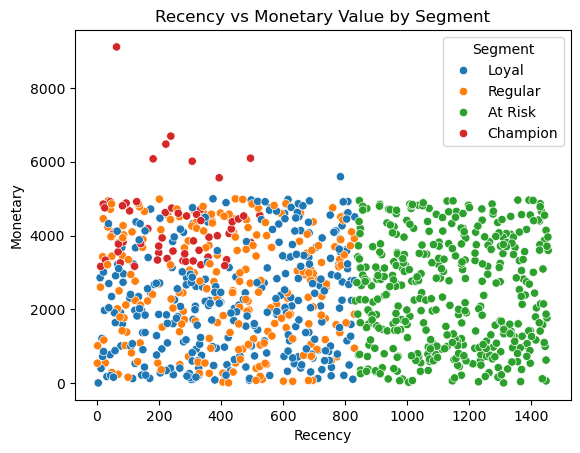

In [11]:
sns.scatterplot(
    data=df.drop_duplicates('CustomerID'),
    x='Recency', y='Monetary', hue='Segment'
)
plt.title('Recency vs Monetary Value by Segment')
plt.show()


In [12]:
TopCustomers = df.groupby('CustomerID')['Sales'].sum().sort_values(ascending=False).head(10)
print('Top 10 customers by sales:\n', TopCustomers)


Top 10 customers by sales:
 CustomerID
CG-22622    9108.35
CG-63143    6693.51
CG-44517    6476.85
CG-51383    6095.41
CG-91962    6077.40
CG-85483    6014.17
CG-80685    5594.63
CG-26389    5565.27
CG-62354    4995.71
CG-17055    4995.50
Name: Sales, dtype: float64


Text(0, 0.5, 'Total Sales')

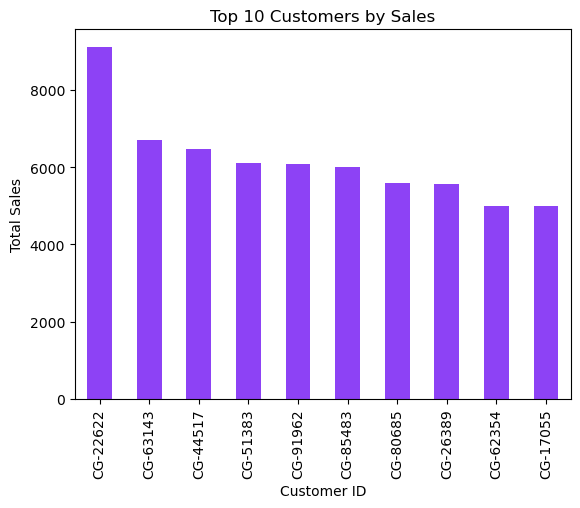

In [15]:
TopCustomers.plot(kind='bar', color = '#8d42f5')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')

# Product AnalysisTop and Bottom Selling Products

## Top and Bottom Selling Products

In [14]:
TopProducts = df.groupby('ProductName')['Sales'].sum().sort_values(ascending=False).head(10)
BottomProducts = df.groupby('ProductName')['Sales'].sum().sort_values().head(10)

Text(0, 0.5, 'Product')

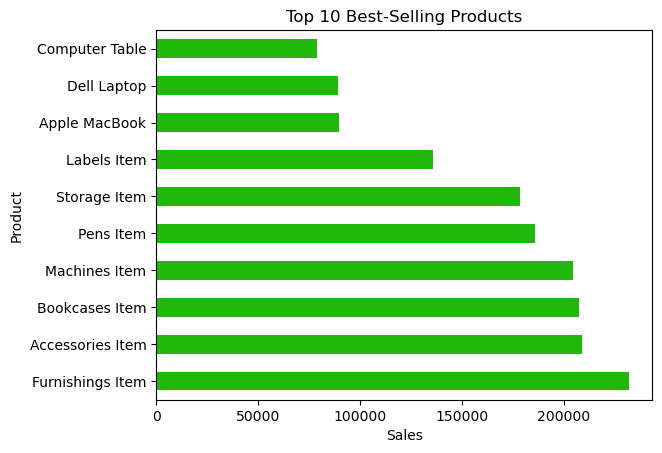

In [18]:
TopProducts.plot(kind='barh', color='#1fb80b')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Sales')
plt.ylabel('Product')

Text(0, 0.5, 'Product')

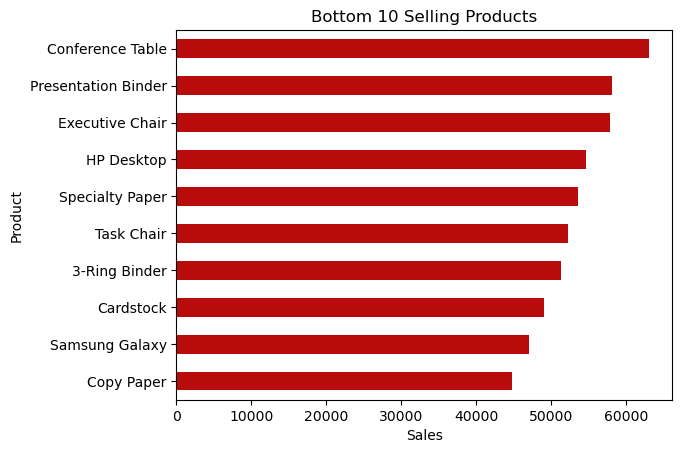

In [19]:
BottomProducts.plot(kind='barh', color='#b80b0b')
plt.title('Bottom 10 Selling Products')
plt.xlabel('Sales')
plt.ylabel('Product')

## Product Margin and Profitability

In [48]:
ProductProfitMargin = (
    df.groupby('ProductName')
      .agg({'Profit': 'sum', 'Sales': 'sum'})
)
ProductProfitMargin['ProfitMargin'] = ProductProfitMargin.apply(
    lambda row: (row['Profit']*100) / row['Sales'] if row['Sales'] != 0 else 0, axis=1
)

TopTenProducts = ProductProfitMargin.sort_values(by='ProfitMargin', ascending=False).head(10)
print(TopTenProducts['ProfitMargin'])



ProductName
Ergonomic Chair     15.126553
Conference Table    14.744815
Accessories Item    13.186333
Furnishings Item    11.577396
Dell Laptop         10.691921
Cardstock           10.610193
3-Ring Binder       10.604523
Samsung Galaxy       9.930592
Storage Item         9.901968
iPhone               9.304222
Name: ProfitMargin, dtype: float64


Text(0, 0.5, 'Product')

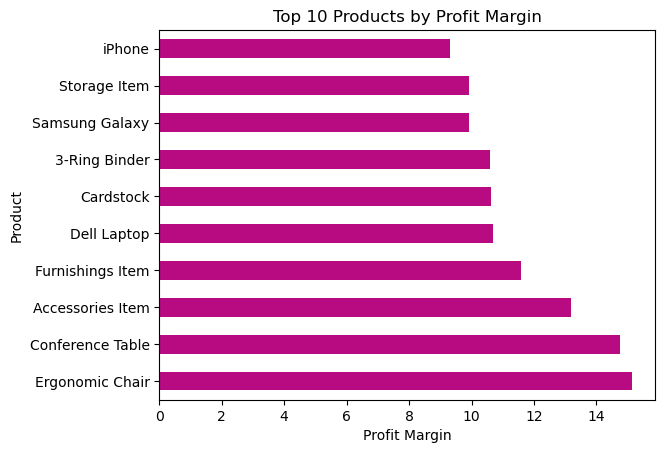

In [50]:
TopTenProducts['ProfitMargin'].plot(kind='barh', color = '#b80b81')
plt.title('Top 10 Products by Profit Margin')
plt.xlabel('Profit Margin')
plt.ylabel('Product')

## ABC Analysis

In [53]:
ProductSales = df.groupby('ProductName')['Sales'].sum().sort_values(ascending=False)
ProductSalesC = ProductSales.cumsum() / ProductSales.sum()
ABCLabels = ['A' if x <= 0.8 else 'B' if x <= 0.95 else 'C' for x in ProductSalesC]
ProductABC = pd.DataFrame({'Sales': ProductSales, 'CumulativePct': ProductSalesC, 'Class': ABCLabels})

In [54]:
print(ProductABC['Class'].value_counts())

Class
A    15
B     7
C     3
Name: count, dtype: int64


Text(0, 0.5, 'Number of Products')

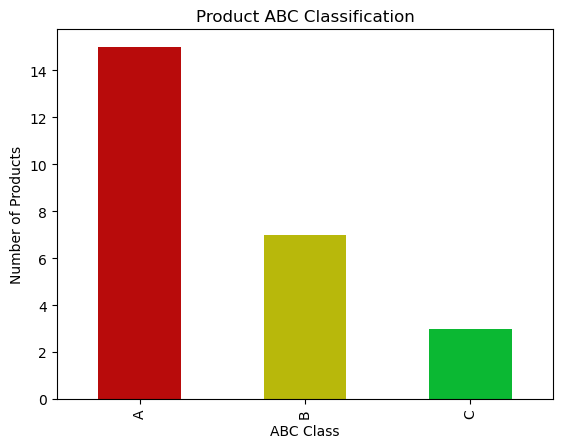

In [57]:
ProductABC['Class'].value_counts().plot(kind='bar', color = ['#b80b0b', '#b8b80b', '#0bb833'])
plt.title('Product ABC Classification')
plt.xlabel('ABC Class')
plt.ylabel('Number of Products')

## Product Sales vs. Quantity

Text(0, 0.5, 'Total Sales')

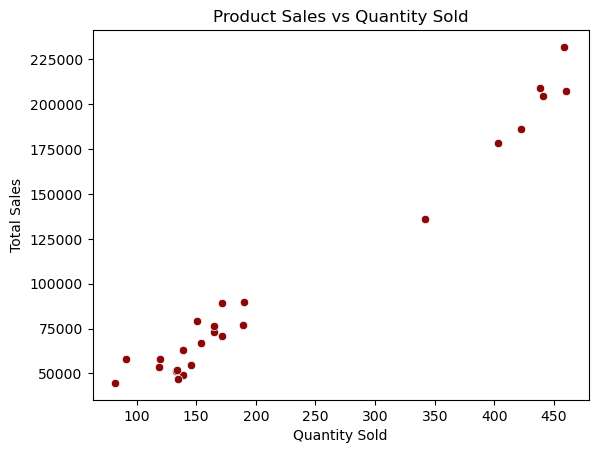

In [59]:
ProductPref = df.groupby('ProductName').agg({'Sales':'sum','Quantity':'sum'})
sns.scatterplot(data=ProductPref, x='Quantity', y='Sales', color = '#8c0707')
plt.title('Product Sales vs Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Total Sales')